# Классификация только по ICA-признакам

ICA-компоненты во времени / их активации по всем компонентам.  
Пайплайн идентичен FFT/ERSP/ERP-блокнота

---
## 1. Импорты, конфиг, параметры

In [8]:
import os, re, time, math, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import mne
from sklearn.decomposition import FastICA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, cross_val_score

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")
plt.rcParams["figure.dpi"] = 110

DATA_DIR       = r"C:\Users\User\Desktop\Python\eeg_files"
FEATURE_DIR    = r"C:\Users\User\Desktop\Python\processed_eeg_files\v24_features"
PREP_CACHE     = os.path.join(FEATURE_DIR, "ica_v2_prep")        # кэш предобработанных эпох
ICA_MODEL_PATH = os.path.join(FEATURE_DIR, "ica_v2_global.pkl")  # сохранённый общий ICA
os.makedirs(PREP_CACHE, exist_ok=True)

FMIN, FMAX       = 0.3, 40.0
EXCLUDE_PATTERNS = ["M1", "M2", "EOG", "WOG"]
ICA_DECIM_SFREQ  = 256
RANDOM_SEED      = 42
N_FOLDS          = 5
CLASSES = ['s1','s2','s3','s4','s5','s6','s7','s8','s9','s10']

TIME_WINDOWS = [
    (0.00,0.05),(0.05,0.10),(0.10,0.15),(0.15,0.20),(0.20,0.28),
    (0.28,0.40),(0.40,0.55),(0.55,0.70),(0.70,1.00),(1.00,1.50),(1.50,2.00),
]
FREQ_BANDS = {"delta":(0.3,4),"theta":(4,8),"alpha":(8,13),"beta":(13,30),"gamma":(30,40)}

N_COMP          = 30        
ICA_MAX_ITER    = 256       
MAX_FIT_SAMPLES = 150_000   
K_BEST          = 150       

files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".set")])
print(f"Файлов: {len(files)} | N_COMP={N_COMP}, max_iter={ICA_MAX_ITER}, K_best(in-fold)={K_BEST}")

Файлов: 46 | N_COMP=30, max_iter=256, K_best(in-fold)=150


---
## 2. Этап A — предобработка

In [9]:
import gc, collections
import scipy.io as sio
from mne.filter import filter_data, resample

def _eeglab_read(set_path):
    mat = sio.loadmat(set_path, squeeze_me=True, struct_as_record=False)
    eeg = mat["EEG"]
    n_ch, n_t, n_tr = int(eeg.nbchan), int(eeg.pnts), int(eeg.trials)
    sfreq, tmin = float(eeg.srate), float(eeg.xmin)
    ch_names = [str(np.atleast_1d(c.labels)[0]) for c in np.atleast_1d(eeg.chanlocs)]

    labels = []
    for ep in np.atleast_1d(eeg.epoch):
        et = ep.eventtype
        if isinstance(et, (int, float, np.integer, np.floating)):
            name = str(et)
        elif isinstance(et, str):
            name = et
        else:                                   # несколько событий в эпохе -> как MNE через "/"
            name = "/".join(str(x) for x in np.atleast_1d(et))
        toks = [t for t in name.split("/") if t in CLASSES]
        labels.append(toks[0] if toks else name)
    labels = np.array(labels)

    data_ref = eeg.data
    if isinstance(data_ref, np.ndarray) and data_ref.dtype.kind in "fiu":
        arr = np.asarray(data_ref, dtype=np.float32)
        if arr.ndim == 2:
            arr = arr.reshape(n_ch, n_t, n_tr, order="F")
        def gen():
            for tr in range(n_tr):
                yield arr[:, :, tr].astype(np.float64)
    else:
        fdt = os.path.join(os.path.dirname(set_path), str(data_ref))
        if not os.path.exists(fdt):
            fdt = set_path[:-4] + ".fdt"
        mm = np.memmap(fdt, dtype=np.float32, mode="r", shape=(n_ch, n_t, n_tr), order="F")
        def gen():
            for tr in range(n_tr):
                yield np.asarray(mm[:, :, tr], dtype=np.float64)   # мкВ (CAL*1e6 = 1)
    return gen(), n_tr, sfreq, tmin, ch_names, labels

def preprocess_file(path):
    cache = os.path.join(PREP_CACHE, os.path.basename(path).replace(".set", "_prep.npz"))
    if os.path.exists(cache):
        d = np.load(cache, allow_pickle=True)
        return d["data"].astype(np.float32), d["lab"], d["times"], list(d["ch"])

    epi, n_tr, sfreq, tmin, ch_names, labels = _eeglab_read(path)
    keep = [i for i, c in enumerate(ch_names)
            if not any(p.upper() in c.upper() for p in EXCLUDE_PATTERNS)]
    kept = [ch_names[i] for i in keep]

    rs = []                                          # ресемпл каждой эпохи отдельно -> мало памяти
    for ep_raw in epi:                               # (n_ch, n_t) мкВ
        x = ep_raw[keep]
        if abs(sfreq - ICA_DECIM_SFREQ) > 1e-6:
            x = resample(x, up=float(ICA_DECIM_SFREQ), down=sfreq, axis=-1, verbose=False)
        rs.append(x.astype(np.float32))
    data = np.stack(rs, 0)                            # (n_tr, n_keep, n_t256)

    sh = data.shape                                  # фильтр 0.3-40 на 256 Гц
    flt = filter_data(data.reshape(-1, sh[-1]).astype(np.float64),
                      float(ICA_DECIM_SFREQ), FMIN, FMAX, verbose=False)
    data = flt.reshape(sh).astype(np.float32)
    times = (tmin + np.arange(sh[-1]) / float(ICA_DECIM_SFREQ)).astype(np.float32)

    np.savez_compressed(cache, data=data.astype(np.float16),
                        lab=labels, times=times, ch=np.array(kept))
    return data, labels, times, kept

def _fdt_size(set_path):
    fdt = set_path[:-4] + ".fdt"
    return os.path.getsize(fdt) if os.path.exists(fdt) else os.path.getsize(set_path)

small = min(files, key=lambda f: _fdt_size(os.path.join(DATA_DIR, f)))
print(f"Проверка на самом маленьком файле: {small}")
data_s, lab_s, t_s, ch_s = preprocess_file(os.path.join(DATA_DIR, small))
uniq    = sorted(set(lab_s))
unknown = [u for u in uniq if u not in CLASSES]
absamp  = np.abs(data_s)
p99     = np.percentile(absamp, 99)
print(f"  форма: {data_s.shape} (эпох, каналов, точек) | каналов после drop: {len(ch_s)}")
print(f"  время: tmin={t_s[0]:.2f}, tmax={t_s[-1]:.2f} с, {ICA_DECIM_SFREQ} Гц")
print(f"  метки: {uniq}")
print(f"  эпох на класс: {dict(collections.Counter(lab_s))}")
print(f"  амплитуда (мкВ): медиана|x|={np.median(absamp):.1f}, 99%={p99:.1f}, max={absamp.max():.1f}")
ok_lab = len(unknown) == 0
ok_amp = np.isfinite(absamp).all() and (p99 < 1000)
print(f"  метки в пределах s1..s10: {ok_lab} | амплитуда в норме (мкВ): {ok_amp}")
if not ok_lab:
    print(f"  ВНИМАНИЕ: незнакомые метки {unknown} — проверка имен событий в .set.")
if not ok_amp:
    print("  ВНИМАНИЕ: амплитуды вне типичного диапазона мкВ — возможна неверная шкала.")
print()

# ---------- собственно Этап A ----------
print("Этап A: предобработка всех файлов + кэш\n")
t0 = time.time()
ch_sets = []
for i, fn in enumerate(files, 1):
    _, _, times_ref, ch = preprocess_file(os.path.join(DATA_DIR, fn))
    ch_sets.append(set(ch)); gc.collect()
    if i % 5 == 0 or i == len(files):
        print(f"  [{i}/{len(files)}] ({time.time()-t0:.0f}с)")

_, _, _, ch_first = preprocess_file(os.path.join(DATA_DIR, files[0]))
common_ch = [c for c in ch_first if all(c in s for s in ch_sets)]
print(f"\nОбщих каналов: {len(common_ch)} (из {len(ch_first)})")
print(f"Точек во времени: {len(times_ref)}")

Проверка на самом маленьком файле: DIRe03_04_Seg3_A22_FCREDIP.set
  форма: (221, 122, 768) (эпох, каналов, точек) | каналов после drop: 122
  время: tmin=-1.00, tmax=2.00 с, 256 Гц
  метки: [np.str_('s1'), np.str_('s10'), np.str_('s2'), np.str_('s3'), np.str_('s4'), np.str_('s5'), np.str_('s6'), np.str_('s7'), np.str_('s8'), np.str_('s9')]
  эпох на класс: {np.str_('s9'): 24, np.str_('s4'): 23, np.str_('s5'): 21, np.str_('s3'): 26, np.str_('s7'): 24, np.str_('s8'): 21, np.str_('s10'): 21, np.str_('s6'): 20, np.str_('s1'): 22, np.str_('s2'): 19}
  амплитуда (мкВ): медиана|x|=5.6, 99%=42.4, max=207.4
  метки в пределах s1..s10: True | амплитуда в норме (мкВ): True

Этап A: предобработка всех файлов + кэш

  [5/46] (3с)
  [10/46] (7с)
  [15/46] (11с)
  [20/46] (15с)
  [25/46] (18с)
  [30/46] (22с)
  [35/46] (26с)
  [40/46] (30с)
  [45/46] (33с)
  [46/46] (34с)

Общих каналов: 122 (из 122)
Точек во времени: 768


---
## 3. Этап B — обучение общего ICA


In [10]:
def reindex(data, ch_names, target):
    idx = [ch_names.index(c) for c in target]
    return data[:, idx, :]

if os.path.exists(ICA_MODEL_PATH):
    with open(ICA_MODEL_PATH, "rb") as f:
        ica = pickle.load(f)
    print(f"Загружен сохранённый global-ICA: {ica.components_.shape[0]} компонент")
else:
    print("Этап B: сбор матрицы и обучение общего ICA...")
    per_file_quota = max(2000, MAX_FIT_SAMPLES // len(files))
    rng = np.random.RandomState(RANDOM_SEED)
    chunks = []
    for fn in files:
        data, _, _, ch = preprocess_file(os.path.join(DATA_DIR, fn))
        data = reindex(data, ch, common_ch)                          # (n_ep,n_ch,n_t)
        M = np.transpose(data, (0, 2, 1)).reshape(-1, len(common_ch))  # (n_ep*n_t, n_ch)
        if M.shape[0] > per_file_quota:
            M = M[rng.choice(M.shape[0], per_file_quota, replace=False)]
        chunks.append(M.astype(np.float32))
    Xfit = np.vstack(chunks)
    print(f"  Матрица для ICA: {Xfit.shape}  (точек × каналов)")
    ica = FastICA(n_components=N_COMP, max_iter=ICA_MAX_ITER,
                  whiten="unit-variance", random_state=RANDOM_SEED)
    t1 = time.time()
    ica.fit(Xfit)
    with open(ICA_MODEL_PATH, "wb") as f:
        pickle.dump(ica, f)
    print(f"  Обучен на {Xfit.shape[0]:,} точках за {time.time()-t1:.0f}с, сохранён.")

Загружен сохранённый global-ICA: 30 компонент


---
## 4. Этап C Извлечение признаков (ERSP)

In [11]:
def feats_from_wave(w, post, wmasks, sfreq):
    f = [w[m].mean() if m.any() else 0.0 for m in wmasks]               # 11 окон
    wp = w[post]; idx = np.where(post)[0]
    f += [wp.max(), wp.min(), float(idx[wp.argmax()]), float(idx[wp.argmin()])]  # 4 экстремума
    n = wp.size                                                          # полосовая мощность
    spec = (np.abs(np.fft.rfft(wp)) / max(n, 1)) ** 2
    fr = np.fft.rfftfreq(n, d=1.0 / sfreq)
    for lo, hi in FREQ_BANDS.values():
        f.append(spec[(fr >= lo) & (fr < hi)].sum())                     # 5 полос
    f.append(wp.max() - wp.min())                                        # размах
    return f

FEATS_PER_COMP = len(TIME_WINDOWS) + 4 + len(FREQ_BANDS) + 1
sfreq = float(ICA_DECIM_SFREQ)
print(f"Этап C: применяю общий ICA, собираю признаки "
      f"({FEATS_PER_COMP}/комп × {N_COMP} = {FEATS_PER_COMP*N_COMP})...\n")

X_ica, y_ica, files_ica = [], [], []
for i, fn in enumerate(files, 1):
    data, lab, t_f, ch = preprocess_file(os.path.join(DATA_DIR, fn))
    data = reindex(data, ch, common_ch)
    n_ep, nt = data.shape[0], data.shape[2]
    post = (t_f >= 0.0) & (t_f <= 2.0)
    wmasks = [((t_f >= a) & (t_f < b)) for (a, b) in TIME_WINDOWS]

    flat = np.transpose(data, (0, 2, 1)).reshape(-1, len(common_ch))     # (n_ep*n_t, n_ch)
    S = ica.transform(flat).reshape(n_ep, nt, N_COMP)
    S = np.transpose(S, (0, 2, 1))                                       # (n_ep, n_comp, n_t)

    for cls in CLASSES:
        m = (lab == cls)
        if not m.any():
            continue
        avg = S[m].mean(0)                                               # (n_comp, n_t)
        vec = []
        for c in range(N_COMP):
            vec += feats_from_wave(avg[c], post, wmasks, sfreq)
        X_ica.append(vec); y_ica.append(cls); files_ica.append(fn)
    if i % 5 == 0 or i == len(files):
        print(f"  [{i}/{len(files)}] {fn}")

X_ica = np.nan_to_num(np.array(X_ica, dtype=np.float32))
y_ica_str = np.array(y_ica)
files_ica = np.array(files_ica)
day_groups_ica = np.array([re.match(r"(DIRe\d+_\d+)", f).group(1) for f in files_ica])
print(f"\nX_ica: {X_ica.shape} | примеров: {len(y_ica_str)} | групп: {len(set(day_groups_ica))}")

Этап C: применяю общий ICA, собираю признаки (21/комп × 30 = 630)...

  [5/46] DIRe01_01_Seg2_A21_FCREDIP.set
  [10/46] DIRe01_03_Seg1_A21_FCREDIP.set
  [15/46] DIRe01_04_Seg3_A20_FCREDIP.set
  [20/46] DIRe01_06_Seg2_A22_FCREDIP.set
  [25/46] DIRe01_08_Seg1_A20_FCREDIP.set
  [30/46] DIRe01_09_Seg3_A20_FCREDIP.set
  [35/46] DIRe02_01_Seg2_A22_FCREDIP.set
  [40/46] DIRe03_04_Seg2_A22_FCREDIP.set
  [45/46] DIRe04_03_Seg3_A22_FCREDIP.set
  [46/46] DIRe04_06_Seg3_A22_FCREDIP.set

X_ica: (460, 630) | примеров: 460 | групп: 17


In [12]:
from sklearn.base import clone

def _reindex(data, ch_names, target):
    idx = [ch_names.index(c) for c in target]
    return data[:, idx, :]

def _feats(w, post, wmasks, sf):
    f = [w[m].mean() if m.any() else 0.0 for m in wmasks]
    wp = w[post]; idx = np.where(post)[0]
    f += [wp.max(), wp.min(), float(idx[wp.argmax()]), float(idx[wp.argmin()])]
    n = wp.size
    spec = (np.abs(np.fft.rfft(wp)) / max(n, 1)) ** 2
    fr = np.fft.rfftfreq(n, d=1.0/sf)
    for lo, hi in FREQ_BANDS.values():
        f.append(spec[(fr >= lo) & (fr < hi)].sum())
    f.append(wp.max() - wp.min())
    return f

def _get_file(fn):
    data, lab, t_f, ch = preprocess_file(os.path.join(DATA_DIR, fn))   # из кэша, быстро
    return _reindex(data, ch, common_ch).astype(np.float32), lab, t_f

def _extract(ica_model):
    X, y, g = [], [], []
    sf = float(ICA_DECIM_SFREQ)
    for fn in files:
        data, lab, t_f = _get_file(fn)
        post = (t_f >= 0.0) & (t_f <= 2.0)
        wmasks = [((t_f >= a) & (t_f < b)) for (a, b) in TIME_WINDOWS]
        n_ep = data.shape[0]
        flat = np.transpose(data, (0, 2, 1)).reshape(-1, len(common_ch))
        S = np.transpose(ica_model.transform(flat).reshape(n_ep, data.shape[2], N_COMP),
                         (0, 2, 1))
        grp = re.match(r"(DIRe\d+_\d+)", fn).group(1)
        for cls in CLASSES:
            m = (lab == cls)
            if not m.any():
                continue
            avg = S[m].mean(0)
            vec = []
            for c in range(N_COMP):
                vec += _feats(avg[c], post, wmasks, sf)
            X.append(vec); y.append(cls); g.append(grp)
        del data, S
    return np.nan_to_num(np.array(X, np.float32)), np.array(y), np.array(g)

def _pergroup_z(X, g):
    Xz = np.zeros_like(X, np.float32)
    for gg in np.unique(g):
        mm = g == gg
        Xz[mm] = StandardScaler().fit_transform(X[mm])
    return Xz

models_pf = {
    "Random Forest": RandomForestClassifier(n_estimators=1500, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED),
    "SVM": SVC(kernel="linear", C=0.1, class_weight="balanced", random_state=RANDOM_SEED),
    "MLP": MLPClassifier(hidden_layer_sizes=(256,128), alpha=0.1, learning_rate_init=0.005,
        max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    "Logistic Regression": LogisticRegression(C=0.1, max_iter=2000, class_weight="balanced",
        solver="lbfgs", n_jobs=-1, random_state=RANDOM_SEED),
    "LDA": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
}

le = LabelEncoder().fit(CLASSES)        # s1..s10 -> int (MLP с early_stopping не любит строки)
groups_arr = np.array([re.match(r"(DIRe\d+_\d+)", fn).group(1) for fn in files])
kbest = min(K_BEST, N_COMP * (len(TIME_WINDOWS) + 4 + len(FREQ_BANDS) + 1))
rng = np.random.RandomState(RANDOM_SEED)
gkf = GroupKFold(n_splits=N_FOLDS)
fold_acc = {n: [] for n in models_pf}

print("Перефолдовый ICA (обучение только на train каждого фолда)...\n")
for fold, (tr_f, te_f) in enumerate(gkf.split(np.arange(len(files)), groups=groups_arr), 1):
    train_files = [files[i] for i in tr_f]
    train_groups = set(groups_arr[tr_f])

    per_quota = max(2000, MAX_FIT_SAMPLES // max(len(train_files), 1))
    chunks = []
    for fn in train_files:
        data, _, _ = _get_file(fn)
        M = np.transpose(data, (0, 2, 1)).reshape(-1, len(common_ch))
        if M.shape[0] > per_quota:
            M = M[rng.choice(M.shape[0], per_quota, replace=False)]
        chunks.append(M.astype(np.float32)); del data
    ica_f = FastICA(n_components=N_COMP, max_iter=ICA_MAX_ITER,
                    whiten="unit-variance", random_state=RANDOM_SEED).fit(np.vstack(chunks))
    del chunks

    Xf, yf, gf = _extract(ica_f)
    yi = le.transform(yf)                          # строки -> int
    Xfz = _pergroup_z(Xf, gf)
    tr_mask = np.isin(gf, list(train_groups))
    te_mask = ~tr_mask
    
    sel = SelectKBest(f_classif, k=min(kbest, Xfz.shape[1])).fit(Xfz[tr_mask], yi[tr_mask])
    Xtr, Xte = sel.transform(Xfz[tr_mask]), sel.transform(Xfz[te_mask])
    for name, mdl in models_pf.items():
        m = clone(mdl).fit(Xtr, yi[tr_mask])
        fold_acc[name].append((m.predict(Xte) == yi[te_mask]).mean())
    print(f"  фолд {fold}/{N_FOLDS}: train={len(train_files)} файлов | "
          f"LDA={fold_acc['LDA'][-1]*100:.1f}%  SVM={fold_acc['SVM'][-1]*100:.1f}%")

print(f"\n{'Модель':<25s} {'Per-fold ICA':>16s}   {'было (global)':>14s}")
print("-" * 60)
global_v2 = {"Random Forest":72.9,"SVM":71.5,"MLP":68.4,
             "Logistic Regression":72.7,"LDA":75.6,"Voting (RF+SVM+MLP)":71.5}
for name in models_pf:
    a = np.array(fold_acc[name])
    print(f"{name:<25s} {a.mean()*100:>7.2f}% ± {a.std()*100:>4.1f}%   "
          f"{global_v2.get(name,float('nan')):>11.1f}%")

Перефолдовый ICA (обучение только на train каждого фолда)...

  фолд 1/5: train=37 файлов | LDA=84.4%  SVM=77.8%
  фолд 2/5: train=37 файлов | LDA=87.8%  SVM=80.0%
  фолд 3/5: train=37 файлов | LDA=91.1%  SVM=87.8%
  фолд 4/5: train=36 файлов | LDA=56.0%  SVM=57.0%
  фолд 5/5: train=37 файлов | LDA=63.3%  SVM=64.4%

Модель                        Per-fold ICA    было (global)
------------------------------------------------------------
Random Forest               72.67% ± 10.3%          72.9%
SVM                         73.40% ± 11.1%          71.5%
MLP                         72.31% ± 10.5%          68.4%
Logistic Regression         74.44% ± 10.1%          72.7%
LDA                         76.53% ± 14.1%          75.6%


---
## 5. Классификация (6 моделей)

In [13]:
Xz = np.zeros_like(X_ica, dtype=np.float32)          # per-group z-score
for g in np.unique(day_groups_ica):
    mm = day_groups_ica == g
    Xz[mm] = StandardScaler().fit_transform(X_ica[mm])

le_i = LabelEncoder().fit(y_ica_str)
y_i = le_i.transform(y_ica_str)
chance = 100 / len(le_i.classes_)
gkf = GroupKFold(n_splits=N_FOLDS)
kbest = min(K_BEST, Xz.shape[1])

def pipe(clf):
    return Pipeline([("sel", SelectKBest(f_classif, k=kbest)), ("clf", clf)])

models = {
    "Random Forest": RandomForestClassifier(n_estimators=1500, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED),
    "SVM": SVC(kernel="linear", C=0.1, class_weight="balanced", random_state=RANDOM_SEED),
    "MLP": MLPClassifier(hidden_layer_sizes=(256,128), alpha=0.1, learning_rate_init=0.005,
        max_iter=500, early_stopping=True, random_state=RANDOM_SEED),
    "Logistic Regression": LogisticRegression(C=0.1, max_iter=2000, class_weight="balanced",
        solver="lbfgs", n_jobs=-1, random_state=RANDOM_SEED),
    "LDA": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
}
models["Voting (RF+SVM+MLP)"] = VotingClassifier(estimators=[
    ("rf",  RandomForestClassifier(n_estimators=1500, max_features="sqrt",
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED)),
    ("svm", SVC(kernel="linear", C=0.1, class_weight="balanced",
            probability=True, random_state=RANDOM_SEED)),
    ("mlp", MLPClassifier(hidden_layer_sizes=(256,128), alpha=0.1, learning_rate_init=0.005,
            max_iter=500, early_stopping=True, random_state=RANDOM_SEED)),
], voting="soft", n_jobs=-1)

print(f"{'Модель':<25s} {'Accuracy':>16s}")
print("-" * 45)
res = {}
for name, mdl in models.items():
    cv = cross_val_score(pipe(mdl), Xz, y_i, cv=gkf, groups=day_groups_ica,
                         scoring="accuracy", n_jobs=-1)
    res[name] = (cv.mean(), cv.std())
    print(f"{name:<25s} {cv.mean()*100:>6.2f}% ± {cv.std()*100:>4.1f}%")

best = max(res, key=lambda n: res[n][0])
print(f"\nЛучшая (global-ICA): {best} ({res[best][0]*100:.2f}%) | случайно {chance:.0f}%")

Модель                            Accuracy
---------------------------------------------
Random Forest              72.89% ± 15.6%
SVM                        71.49% ± 11.4%
MLP                        68.40% ± 12.0%
Logistic Regression        72.71% ± 11.9%
LDA                        75.60% ± 12.7%
Voting (RF+SVM+MLP)        71.49% ± 13.4%

Лучшая (global-ICA): LDA (75.60%) | случайно 10%


---
## 6. График 

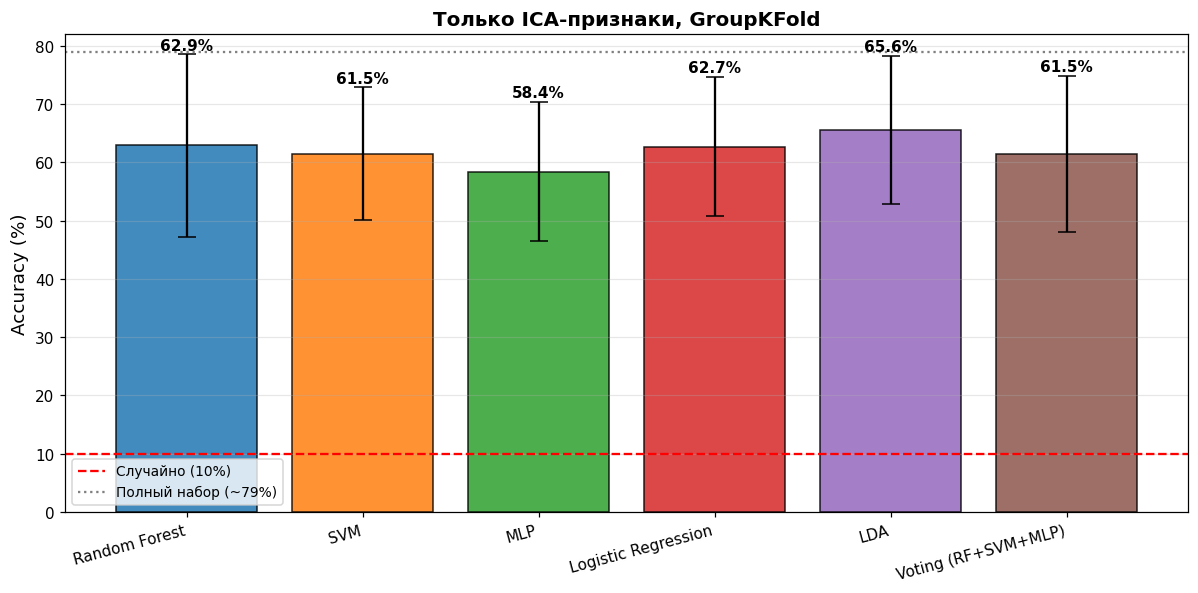

In [14]:
fig, ax = plt.subplots(figsize=(11, 5.5))
names = list(res.keys())
vals  = [res[n][0] * 100-10 for n in names]
errs  = [res[n][1] * 100 for n in names]
ax.bar(names, vals, yerr=errs, capsize=6, color=plt.cm.tab10(np.arange(len(names))),
       alpha=0.85, edgecolor="black", linewidth=1)
ax.axhline(chance, ls="--", color="red", lw=1.5, label=f"Случайно ({chance:.0f}%)")
ax.axhline(79, ls=":", color="gray", lw=1.5, label="Полный набор (~79%)")
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Только ICA-признаки, GroupKFold", fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(max(vals) * 1.25, 40))
plt.xticks(rotation=15, ha="right")
for i, (v, e) in enumerate(zip(vals, errs)):
    ax.text(i, v + e + 0.8, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()